# Informal results script for experimental results mid-development

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
%%javascript
IPython.notebook.kernel.execute('nb_name = "' + IPython.notebook.notebook_name + '"')

import os
import sys

sys.path.append(os.path.join(os.path.dirname(nb_name), '..'))

<IPython.core.display.Javascript object>

In [3]:
from plotting_functions import create_pearsons_violin

# Pre-modification results to identify gene subset to target

In [4]:
DATA_ROOT = '../data'
results = pd.read_csv(f'{DATA_ROOT}/Pearsons_results.csv', index_col = 0, header = 0)

In [5]:
negative_correlations = results[results['train_loss'] > 1]
negative_correlations['train_pearsons'] = 1 - negative_correlations['train_loss']
negative_correlations['test_pearsons'] = 1 - negative_correlations['test_loss']

In [6]:
negative_correlations_to_plot = negative_correlations[['train_pearsons', 'test_pearsons']]
negative_correlations_to_plot.columns = ['Train', 'Test']
negative_correlations_to_plot = negative_correlations_to_plot.melt()
negative_correlations_to_plot.columns = ['dataset', 'pearsons']
negative_correlations_to_plot

,dataset,pearsons
0,Train,-0.259466
1,Train,-0.125649
2,Train,-0.162875
3,Train,-0.071197
4,Train,-0.558364
...,...,...
1783,Test,-0.043532
1784,Test,-0.353516
1785,Test,-0.160862
1786,Test,0.004316


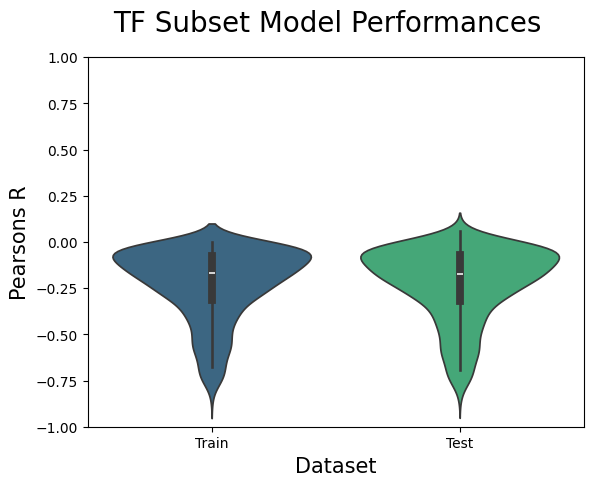

In [7]:
create_pearsons_violin(negative_correlations_to_plot, y_col = 'pearsons', title = 'TF Subset Model Performances', figure_root = './figures/experimental_figures/', file_title = 'subset_TFS')

# Post-modification results to asssess change impacts

In [8]:
exp_results = pd.read_csv('../model_building/data/EXPERIMENTAL_results.csv', index_col = 0)

In [9]:
exp_results['train_pearsons'] = 1 - exp_results['train_loss']
exp_results['test_pearsons'] = 1 - exp_results['test_loss']

In [10]:
exp_results

,train_loss,test_loss,stopped_early,in_features,train_pearsons,test_pearsons
AARD,0.879383,0.887594,1.0,13,0.120617,0.112406
ABCA12,0.815711,0.815742,NaN,22,0.184289,0.184258
ABCA13,0.518095,0.538852,1.0,4,0.481905,0.461148
ABRA,1.053751,1.061039,1.0,2,-0.053751,-0.061039
ACMSD,0.562610,0.557208,1.0,2,0.437390,0.442792
...,...,...,...,...,...,...
ZNHIT3,0.870259,0.837725,1.0,2,0.129741,0.162275
ZNHIT6,1.424912,1.435573,1.0,8,-0.424912,-0.435573
ZPBP,0.719384,0.704535,1.0,11,0.280616,0.295465
ZSWIM2,0.708791,0.685221,NaN,30,0.291209,0.314779


In [11]:
#transfrom dataframe to work with create_pearsons_violin
to_plot_df = exp_results[['train_pearsons', 'test_pearsons']]
to_plot_df.columns = ['Train', 'Test']
to_plot_df = to_plot_df.melt()
to_plot_df.columns = ['dataset', 'pearsons']

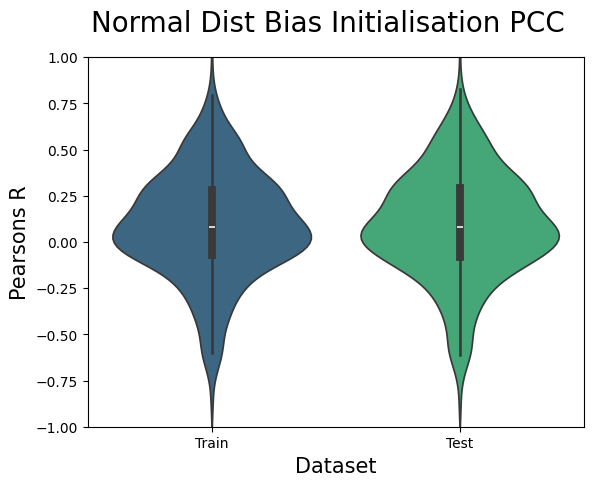

In [15]:
create_pearsons_violin(to_plot_df, y_col = 'pearsons', title = 'Normal Dist Bias Initialisation PCC', figure_root = './figures/experimental_figures/', file_title = 'randn_bias_init', ylim = (-1, 1))

In [13]:
exp_results['train_pearsons'].describe()

count    894.000000
mean       0.087790
std        0.291157
min       -0.891292
25%       -0.073025
50%        0.081668
75%        0.280564
max        0.993994
Name: train_pearsons, dtype: float64

<Axes: ylabel='train_pearsons'>

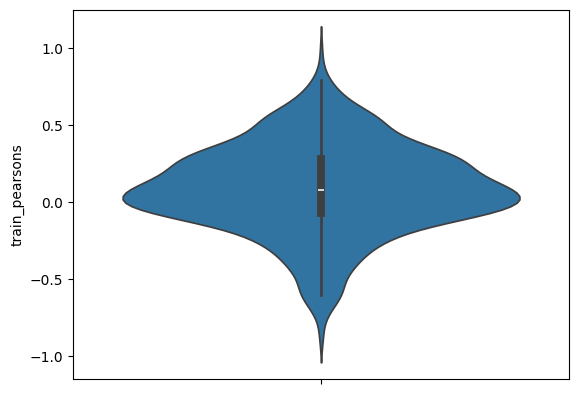

In [14]:
sns.violinplot(exp_results['train_pearsons'])